In [1]:
import torchvision
# For image transforms
from torchvision import transforms
# For DATA SET
import torchvision.datasets as datasets
# For Pytorch methods
import torch
import torch.nn as nn
# For Optimizer
import torch.optim as optim
# FOR DATA LOADER
from torch.utils.data import DataLoader
# FOR TENSOR BOARD VISUALIZATION
from torch.utils.tensorboard import SummaryWriter # to print to tensorboard

In [2]:
# Hyperparameters
device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
lr = 1e-4
batchSize = 32  # Batch size
numEpochs = 100
logStep = 625  # the number of steps to log the images and losses to tensorboard

latent_dimension = 128 # 64, 128, 256
# for simplicity we will flatten the image to a vector and to use simple MLP networks
# 28 * 28 * 1 flattens to 784
# you are also free to use CNNs
image_dimension = 28 * 28 * 1  # 784

In [3]:
# we define a tranform that converts the image to tensor and normalizes it with mean and std of 0.5
# which will convert the image range from [0, 1] to [-1, 1]
myTransforms = transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.5,), (0.5,))])


In [4]:

# the MNIST dataset is available through torchvision.datasets
print("loading MNIST digits dataset")
dataset = datasets.MNIST(root="dataset/", transform=myTransforms, download=True)
# let's create a dataloader to load the data in batches
loader = DataLoader(dataset, batch_size=batchSize, shuffle=True)


loading MNIST digits dataset


100%|██████████| 9.91M/9.91M [00:00<00:00, 41.6MB/s]

100%|██████████| 28.9k/28.9k [00:00<00:00, 1.09MB/s]

100%|██████████| 1.65M/1.65M [00:00<00:00, 10.1MB/s]

100%|██████████| 4.54k/4.54k [00:00<00:00, 2.53MB/s]



In [5]:

class Generator(nn.Module):
    """
    Generator Model
    """
    def __init__(self):
        super().__init__()
        self.gen = nn.Sequential(
            nn.Linear(latent_dimension, latent_dimension * 2), 
            nn.LeakyReLU(0.2),
            nn.Linear(latent_dimension * 2, latent_dimension * 4), 
            nn.LeakyReLU(0.2),
            nn.Linear(latent_dimension * 4, latent_dimension * 8), 
            nn.LeakyReLU(0.2),
            nn.Linear(latent_dimension * 8, image_dimension),
            nn.Tanh()
              # It is helpful to use the tanh activation function to force the ouput into the [-1,1] range that our normalized images have.
        )

    def forward(self, x):
        return self.gen(x)



In [6]:


class Discriminator(nn.Module):
    """
    Discriminator Model
    """
    def __init__(self):
        super().__init__()
        self.disc = nn.Sequential(
            nn.Linear(image_dimension, latent_dimension * 4),
            nn.LeakyReLU(0.2),
            nn.Linear(latent_dimension * 4, latent_dimension * 2),
            nn.LeakyReLU(0.2),
            nn.Linear(latent_dimension * 2, latent_dimension),
            nn.LeakyReLU(0.2),
            nn.Linear(latent_dimension, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.disc(x)


In [7]:
# Check for available devices and select if available
if torch.cuda.is_available():
    device = torch.device("cuda")       #CUDA GPU
elif torch.backends.mps.is_available():
    device = torch.device("mps")        #Apple GPU
else:
    device = torch.device("cpu")        #if nothing is found use the CPU
print(f"Using device: {device}")

Using device: cpu


In [8]:
# initialize networks and optimizers
discriminator = Discriminator().to(device)
generator = Generator().to(device)
opt_discriminator = optim.Adam(discriminator.parameters(), lr=lr)
opt_generator = optim.Adam(generator.parameters(), lr=lr)


In [9]:

# This is a binary classification task, so we use Binary Cross Entropy Loss
criterion = nn.BCELoss()


In [10]:
# Initialize fixed noise for visualization and TensorBoard writer
fixed_noise = torch.randn(32, latent_dimension).to(device)
writer = SummaryWriter()

# Dictionary to store generator checkpoints at specific epochs
generator_checkpoints = {}
checkpoint_epochs = [1, 5, 10, 20]

# Training Loop
step = 0
print("Started Training and visualization...")
for epoch in range(numEpochs):
    # loop over batches
    print()
    for batch_idx, (real, _) in enumerate(loader):
        # First we train the discriminator on real images vs. generated images

        # Get the real images and flatten them
        # for simplicity, we flatten the image to a vector and to use simple MLP networks
        # 28 * 28 * 1 flattens to 784
        real = real.view(-1, 784).to(device)
        batch_size = real.shape[0]

        # Labels for real and fake images
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # Step 1) generate fake images
        noise = torch.randn(batch_size, latent_dimension).to(device)
        fake = generator(noise)

        # Step 2) Train Discriminator:
        # - predict the discriminator output for real images
        # - real images are labeled as 1
        # - calculate the loss for real images
        real_pred = discriminator(real)
        loss_real = criterion(real_pred, real_labels)

        # - predict the discriminator output for fake images
        # - fake images are labeled as 0
        # - calculate the loss for fake images
        fake_pred = discriminator(fake.detach())
        loss_fake = criterion(fake_pred, fake_labels)

        # - average the loss for real and fake images
        loss_discriminator = (loss_real + loss_fake) / 2

        # - now update the weights of the discriminator by backpropagating the loss through the discriminator
        # the generator is not updated in this step
        opt_discriminator.zero_grad()
        loss_discriminator.backward()
        opt_discriminator.step()

        # Train Generator:
        # Now train the generator by generating fake images and passing them through the discriminator
        # We use the trick of training the generator to maximize the probability of the discriminator
        # predicting the fake images as real.
        fake = generator(noise)
        fake_pred = discriminator(fake)
        loss_generator = criterion(fake_pred, real_labels)

        opt_generator.zero_grad()
        loss_generator.backward()
        opt_generator.step()

        # print the progress
        print(f"\rEpoch [{epoch}/{numEpochs}] Batch {batch_idx}/{len(loader)} \ Loss discriminator: {loss_discriminator:.4f}, loss generator: {loss_generator:.4f}", end="")

        # Log the losses and example images to tensorboard
        if batch_idx % logStep == 0:
            with torch.no_grad():
                # Generate noise via Generator, we always use the same noise to see the progression
                fake = generator(fixed_noise).reshape(-1, 1, 28, 28)
                # Get real data
                data = real.reshape(-1, 1, 28, 28)
                # make grid of pictures and add to tensorboard
                imgGridFake = torchvision.utils.make_grid(fake, normalize=True)
                imgGridReal = torchvision.utils.make_grid(data, normalize=True)

            writer.add_image("Generated", imgGridFake, step)
            writer.add_image("Real", imgGridReal, step)
            writer.add_scalar("Loss/Discriminator", loss_discriminator.item(), step)
            writer.add_scalar("Loss/Generator", loss_generator.item(), step)

            # increment step
            step += 1
    
    # Save generator checkpoint at specific epochs
    if epoch + 1 in checkpoint_epochs:
        generator_checkpoints[epoch + 1] = Generator().to(device)
        generator_checkpoints[epoch + 1].load_state_dict(generator.state_dict())
        print(f" [Checkpoint saved at epoch {epoch + 1}]")

<>:67: SyntaxWarning: invalid escape sequence '\ '
<>:67: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_7919/2111919248.py:67: SyntaxWarning: invalid escape sequence '\ '
  print(f"\rEpoch [{epoch}/{numEpochs}] Batch {batch_idx}/{len(loader)} \ Loss discriminator: {loss_discriminator:.4f}, loss generator: {loss_generator:.4f}", end="")


Started Training and visualization...

Epoch [0/100] Batch 1874/1875 \ Loss discriminator: 0.4667, loss generator: 1.1214 [Checkpoint saved at epoch 1]

Epoch [0/100] Batch 1874/1875 \ Loss discriminator: 0.4667, loss generator: 1.1214 [Checkpoint saved at epoch 1]

Epoch [1/100] Batch 1874/1875 \ Loss discriminator: 0.2719, loss generator: 2.2249
Epoch [1/100] Batch 1874/1875 \ Loss discriminator: 0.2719, loss generator: 2.2249
Epoch [2/100] Batch 1874/1875 \ Loss discriminator: 0.2231, loss generator: 1.8609
Epoch [2/100] Batch 1874/1875 \ Loss discriminator: 0.2231, loss generator: 1.8609
Epoch [3/100] Batch 1874/1875 \ Loss discriminator: 0.1821, loss generator: 4.0919
Epoch [3/100] Batch 1874/1875 \ Loss discriminator: 0.1821, loss generator: 4.0919
Epoch [4/100] Batch 1874/1875 \ Loss discriminator: 0.1602, loss generator: 2.8289 [Checkpoint saved at epoch 5]

Epoch [4/100] Batch 1874/1875 \ Loss discriminator: 0.1602, loss generator: 2.8289 [Checkpoint saved at epoch 5]

Epoch [

KeyboardInterrupt: 

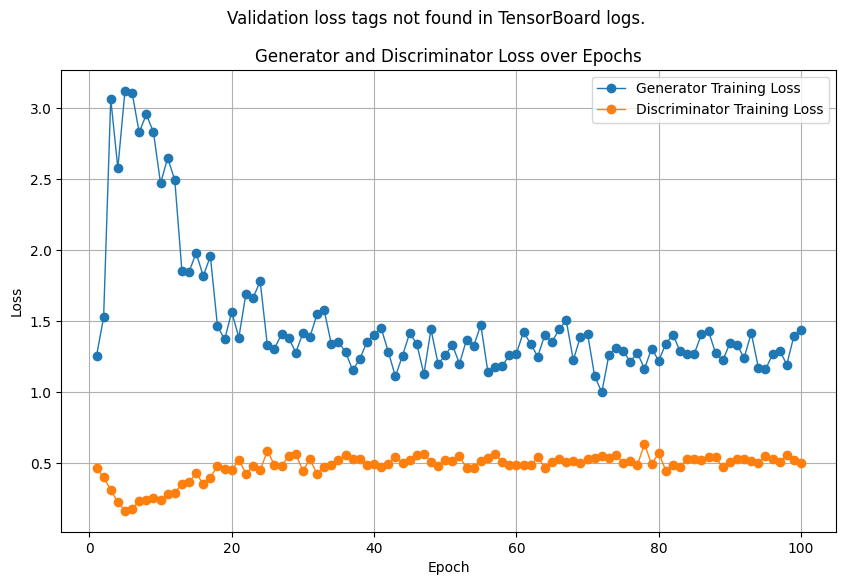

In [11]:
from tensorboard.backend.event_processing import event_accumulator

import matplotlib.pyplot as plt

log_dir = writer.log_dir if "writer" in globals() else "runs"
ea = event_accumulator.EventAccumulator(
    log_dir,
    size_guidance={
        event_accumulator.COMPRESSED_HISTOGRAMS: 0,
        event_accumulator.IMAGES: 0,
        event_accumulator.AUDIO: 0,
        event_accumulator.SCALARS: 1000,
        event_accumulator.HISTOGRAMS: 0,
    },
)
ea.Reload()

def get_scalar_values(tag):
    if tag in ea.Tags().get("scalars", []):
        return [event.value for event in ea.Scalars(tag)]
    return None

train_disc = get_scalar_values("Loss/Discriminator")
train_gen = get_scalar_values("Loss/Generator")
val_disc = get_scalar_values("Val/Loss/Discriminator")
val_gen = get_scalar_values("Val/Loss/Generator")

if train_disc is None or train_gen is None:
    raise RuntimeError("Training loss scalars not found in TensorBoard logs.")

def aggregate_to_epochs(values, epochs):
    if len(values) == epochs:
        return values
    points_per_epoch = len(values) // epochs if epochs and len(values) % epochs == 0 else None
    if points_per_epoch:
        return [
            sum(values[i * points_per_epoch : (i + 1) * points_per_epoch]) / points_per_epoch
            for i in range(epochs)
        ]
    return values

train_disc_epoch = aggregate_to_epochs(train_disc, numEpochs)
train_gen_epoch = aggregate_to_epochs(train_gen, numEpochs)
val_disc_epoch = aggregate_to_epochs(val_disc, numEpochs) if val_disc is not None else None
val_gen_epoch = aggregate_to_epochs(val_gen, numEpochs) if val_gen is not None else None

epochs = list(range(1, len(train_disc_epoch) + 1))

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_gen_epoch, label="Generator Training Loss", marker="o", linewidth=1)
plt.plot(epochs, train_disc_epoch, label="Discriminator Training Loss", marker="o", linewidth=1)

if val_gen_epoch is not None:
    plt.plot(epochs, val_gen_epoch, label="Generator Validation Loss", linestyle="--", linewidth=1)
if val_disc_epoch is not None:
    plt.plot(epochs, val_disc_epoch, label="Discriminator Validation Loss", linestyle="--", linewidth=1)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Generator and Discriminator Loss over Epochs")
plt.legend()
plt.grid(True)

if val_gen_epoch is None and val_disc_epoch is None:
    plt.suptitle("Validation loss tags not found in TensorBoard logs.")
plt.show()

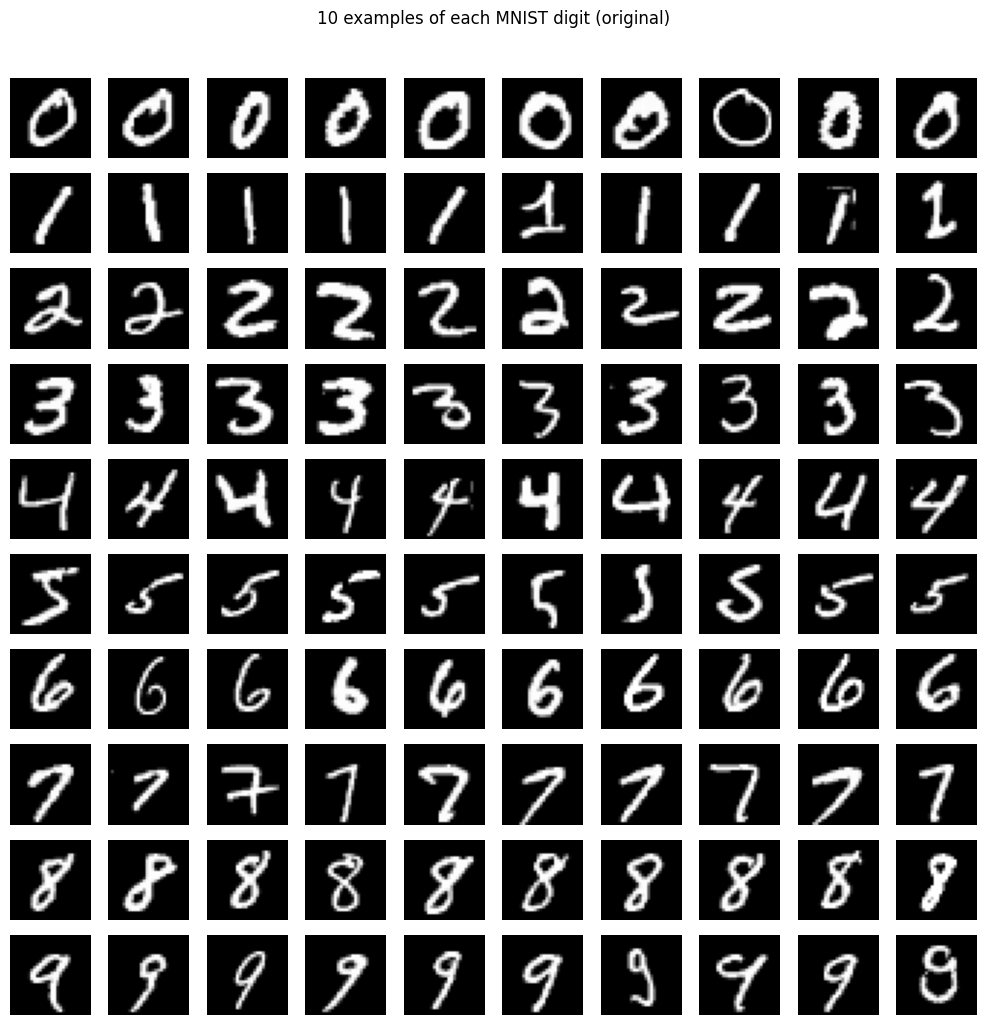

Classifier epoch 1/2, accuracy: 0.8326
Classifier epoch 2/2, accuracy: 0.9175
Classifier epoch 2/2, accuracy: 0.9175


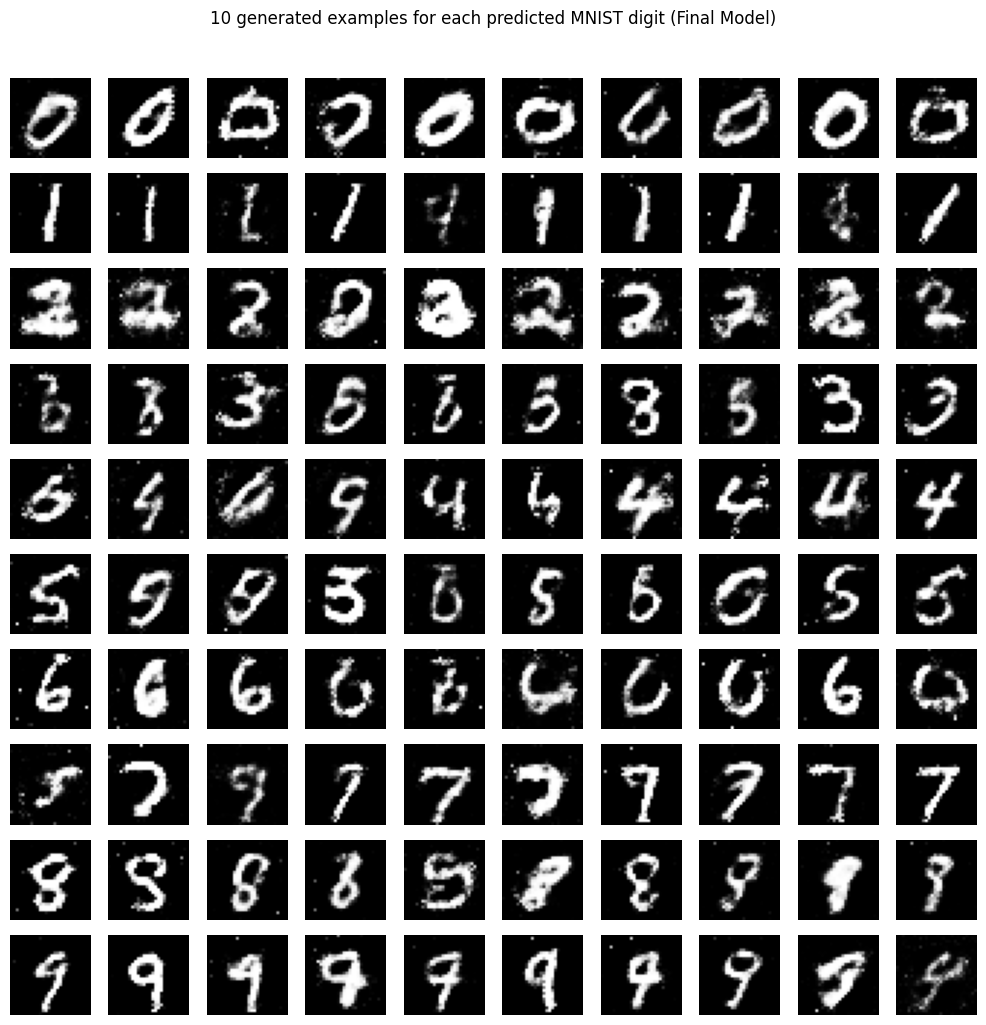

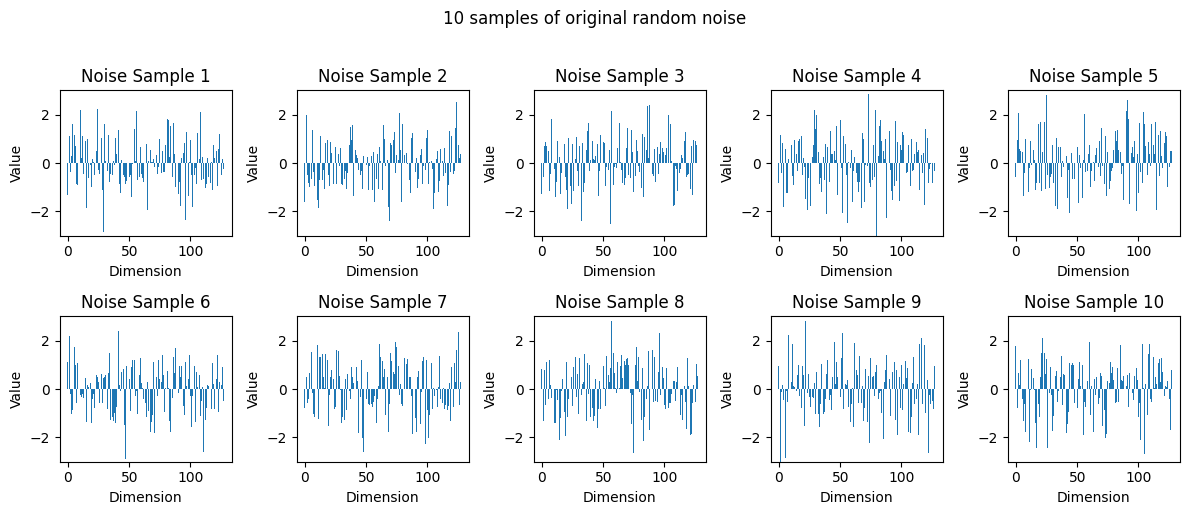

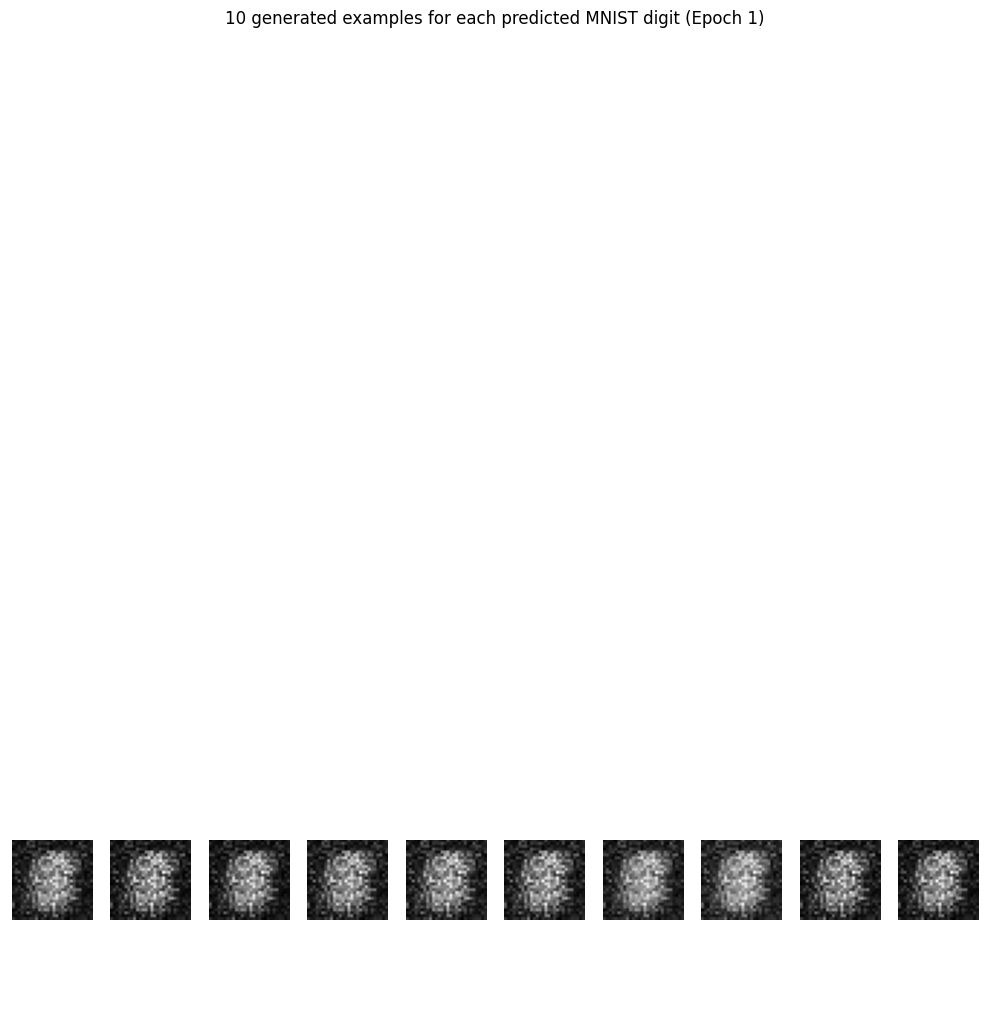

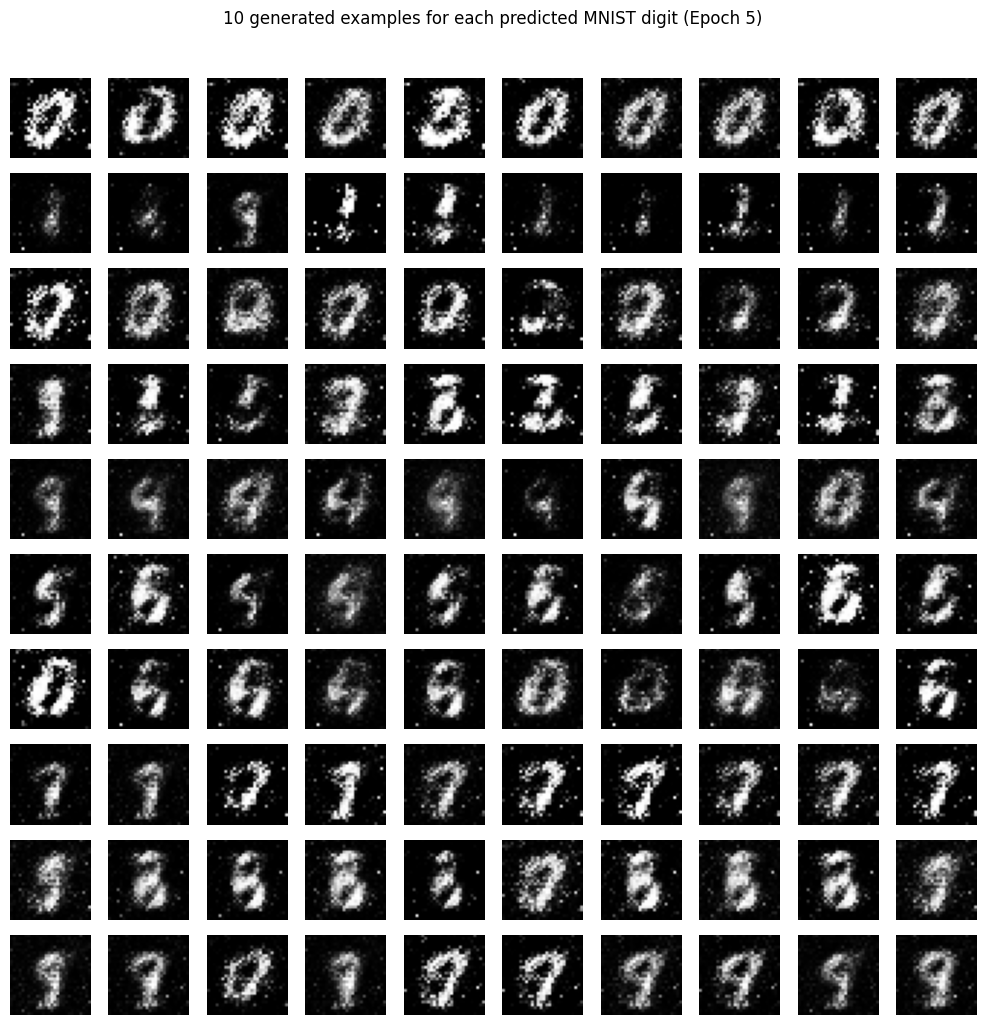

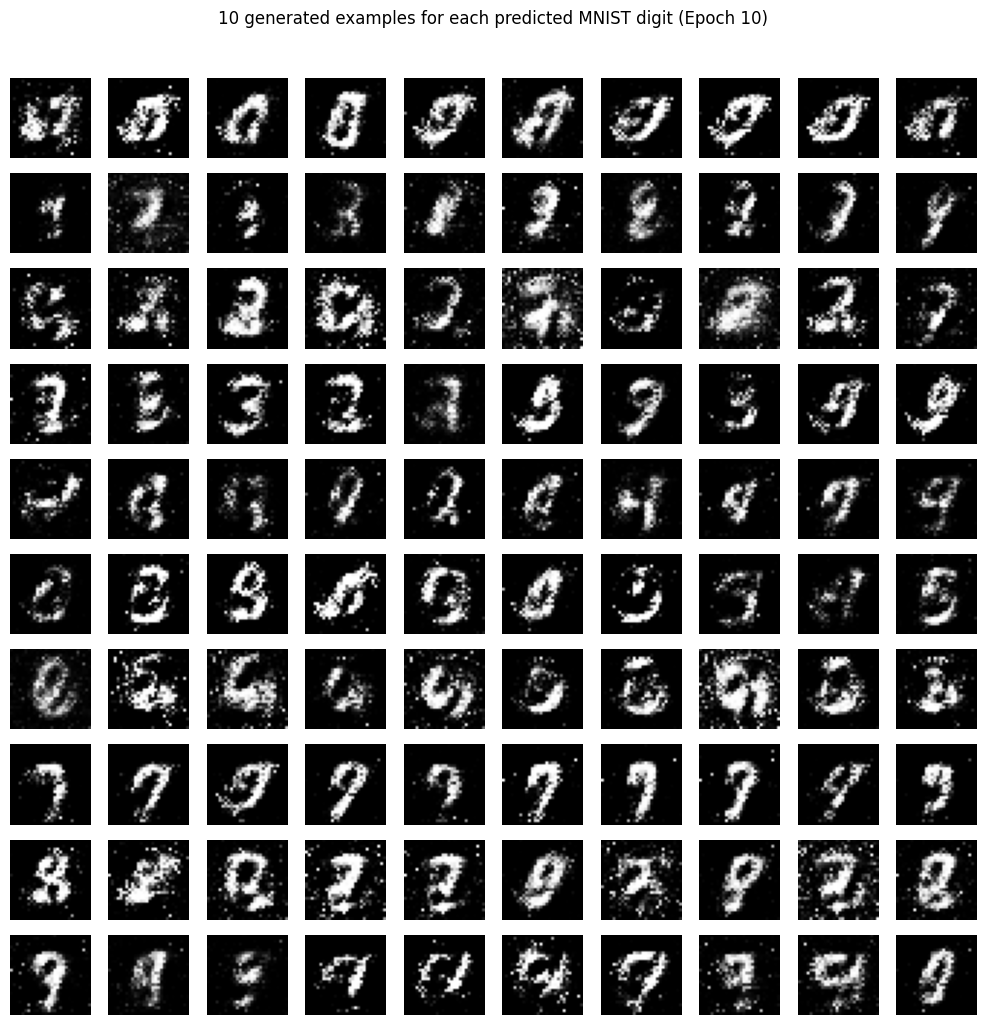

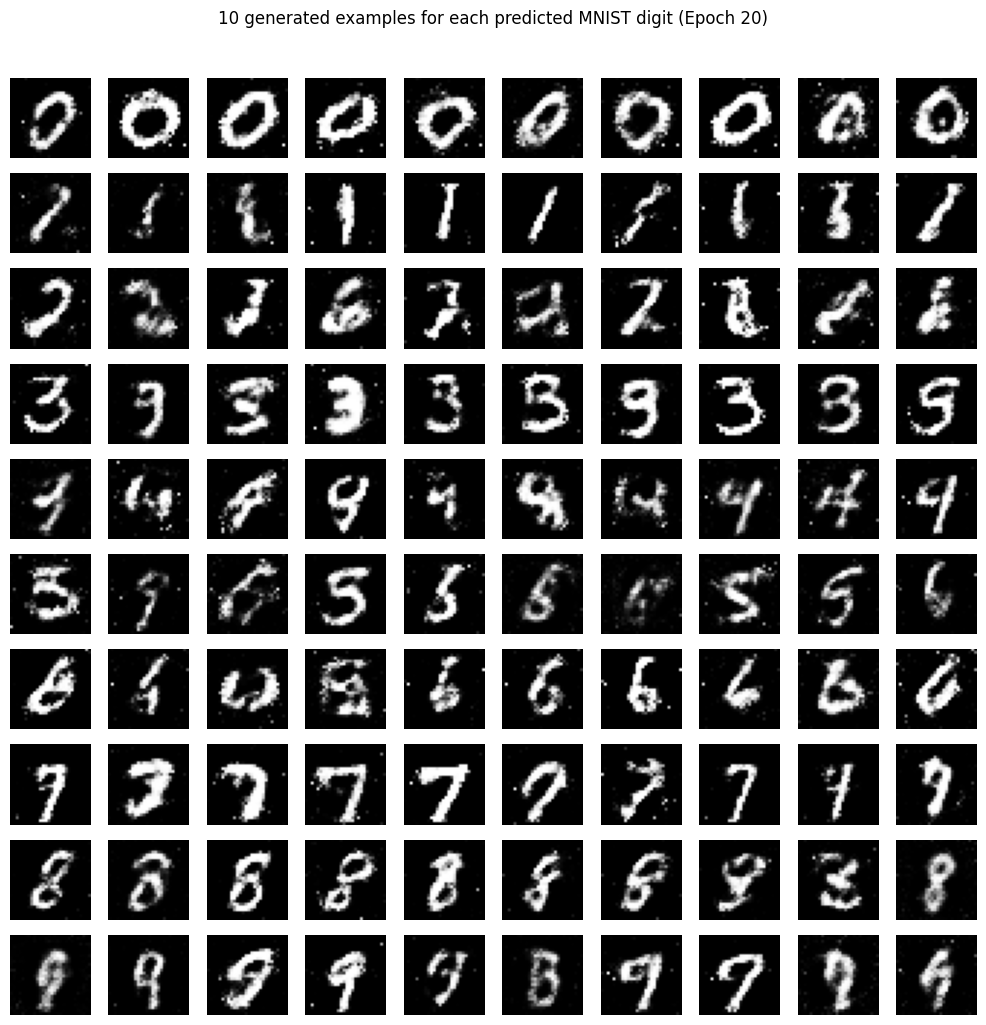

In [11]:
import matplotlib.pyplot as plt

# Plot 10 real MNIST examples for each digit
original_examples = []
for digit in range(10):
    digit_indices = (dataset.targets == digit).nonzero(as_tuple=True)[0][:10]
    original_examples.append(dataset.data[digit_indices])

fig, axes = plt.subplots(10, 10, figsize=(10, 10))
for digit in range(10):
    for i in range(10):
        ax = axes[digit, i]
        ax.imshow(original_examples[digit][i], cmap="gray")
        ax.axis("off")
        if i == 0:
            ax.set_ylabel(str(digit), rotation=0, labelpad=20, va="center")

fig.suptitle("10 examples of each MNIST digit (original)", y=1.02)
plt.tight_layout()
plt.show()

# Train a small MNIST classifier so we can group generated samples by digit
class MNISTClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(image_dimension, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.net(x)

classifier = MNISTClassifier().to(device)
opt_classifier = optim.Adam(classifier.parameters(), lr=1e-3)
criterion_classifier = nn.CrossEntropyLoss()
classifier_loader = DataLoader(dataset, batch_size=512, shuffle=True)

for epoch_cls in range(2):
    classifier.train()
    total = 0
    correct = 0
    for images, labels in classifier_loader:
        images = images.view(-1, image_dimension).to(device)
        labels = labels.to(device)
        outputs = classifier(images)
        loss = criterion_classifier(outputs, labels)

        opt_classifier.zero_grad()
        loss.backward()
        opt_classifier.step()

        preds = outputs.argmax(dim=1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    accuracy = correct / total
    print(f"Classifier epoch {epoch_cls + 1}/2, accuracy: {accuracy:.4f}")

# Generate samples and group them by predicted digit from final model
generator.eval()
classifier.eval()

generated_by_digit = [[] for _ in range(10)]
max_batches = 40
batch_size_gen = 256

with torch.no_grad():
    for _ in range(max_batches):
        noise = torch.randn(batch_size_gen, latent_dimension).to(device)
        fake_images = generator(noise)
        outputs = classifier(fake_images)
        preds = outputs.argmax(dim=1).cpu()

        for img, pred in zip(fake_images.cpu(), preds):
            if len(generated_by_digit[pred.item()]) < 10:
                generated_by_digit[pred.item()].append(img)

        if all(len(samples) == 10 for samples in generated_by_digit):
            break

# Plot generated examples grouped by predicted digit for final model
fig, axes = plt.subplots(10, 10, figsize=(10, 10))
for digit in range(10):
    for i in range(10):
        ax = axes[digit, i]
        if i < len(generated_by_digit[digit]):
            img = generated_by_digit[digit][i].view(28, 28)
            img = (img + 1.0) / 2.0  # from [-1, 1] to [0, 1]
            ax.imshow(img, cmap="gray")
        ax.axis("off")
        if i == 0:
            ax.set_ylabel(str(digit), rotation=0, labelpad=20, va="center")

fig.suptitle("10 generated examples for each predicted MNIST digit (Final Model)", y=1.02)
plt.tight_layout()
plt.show()

# Plot original noise
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()
for i in range(10):
    ax = axes[i]
    noise_sample = torch.randn(1, latent_dimension).to(device)
    ax.bar(range(latent_dimension), noise_sample.cpu().numpy()[0])
    ax.set_title(f"Noise Sample {i+1}")
    ax.set_xlabel("Dimension")
    ax.set_ylabel("Value")
    ax.set_ylim(-3, 3)

plt.suptitle("10 samples of original random noise", y=1.02)
plt.tight_layout()
plt.show()

# Function to generate and plot samples from a checkpoint
def plot_checkpoint_samples(checkpoint_gen, checkpoint_epoch):
    checkpoint_gen.eval()
    generated_by_digit_ckpt = [[] for _ in range(10)]
    
    with torch.no_grad():
        for _ in range(max_batches):
            noise = torch.randn(batch_size_gen, latent_dimension).to(device)
            fake_images = checkpoint_gen(noise)
            outputs = classifier(fake_images)
            preds = outputs.argmax(dim=1).cpu()
            
            for img, pred in zip(fake_images.cpu(), preds):
                if len(generated_by_digit_ckpt[pred.item()]) < 10:
                    generated_by_digit_ckpt[pred.item()].append(img)
            
            if all(len(samples) == 10 for samples in generated_by_digit_ckpt):
                break
    
    fig, axes = plt.subplots(10, 10, figsize=(10, 10))
    for digit in range(10):
        for i in range(10):
            ax = axes[digit, i]
            if i < len(generated_by_digit_ckpt[digit]):
                img = generated_by_digit_ckpt[digit][i].view(28, 28)
                img = (img + 1.0) / 2.0  # from [-1, 1] to [0, 1]
                ax.imshow(img, cmap="gray")
            ax.axis("off")
            if i == 0:
                ax.set_ylabel(str(digit), rotation=0, labelpad=20, va="center")
    
    fig.suptitle(f"10 generated examples for each predicted MNIST digit (Epoch {checkpoint_epoch})", y=1.02)
    plt.tight_layout()
    plt.show()

# Plot samples from each checkpoint
for epoch_num in sorted(generator_checkpoints.keys()):
    plot_checkpoint_samples(generator_checkpoints[epoch_num], epoch_num)